<a href="https://colab.research.google.com/github/mirakhmadovdilshod/Classification-task-with-nested-cv/blob/main/Breast_cancer_classification_nestedCV_commented.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
# CELL 1.5: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 2: Load dataset from Google Drive

import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/data.csv'
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nFirst rows:")
print(df.head())

Shape: (569, 33)
Columns: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']

First rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58 

In [ ]:
# CELL 2b: Separate X and y

X = df.drop(columns=['id', 'diagnosis'], errors='ignore')

X = X.dropna(axis=1, how='all')
y = df['diagnosis'].map({'M': 0, 'B': 1})

print("X shape:", X.shape)
print("y distribution:")
print(y.value_counts())
print("\n0 = Malignant, 1 = Benign")

X shape: (569, 30)
y distribution:
diagnosis
1    357
0    212
Name: count, dtype: int64

0 = Malignant, 1 = Benign


In [ ]:
# CELL 3: EDA — Basic dataset info

print("Shape of X:", X.shape)

print("\nBasic statistics:")
print(X.describe())

print("\nMissing values per feature:")
print(X.isnull().sum().sum(), "total missing values")

duplicates = X.duplicated().sum()
print("\nNumber of duplicate samples:", duplicates)

Shape of X: (569, 30)

Basic statistics:
       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0

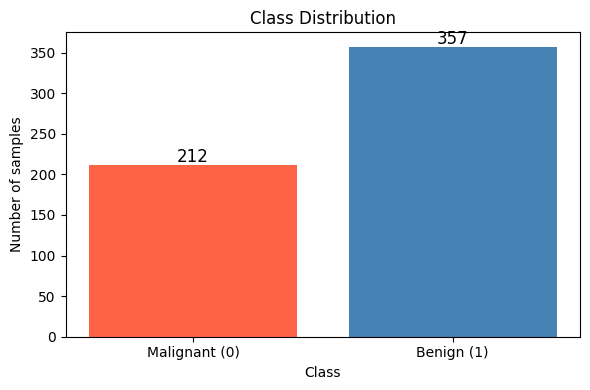

In [ ]:
# CELL 4: EDA — Class distribution (Bar plot)

class_counts = y.value_counts().sort_index() #bug .sort_index was added to fix it

class_names = ['Malignant (0)', 'Benign (1)']

plt.figure(figsize=(6, 4))

plt.bar(class_names, class_counts, color=['tomato', 'steelblue'])

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of samples')

for i, count in enumerate(class_counts):
    plt.text(i, count + 3, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

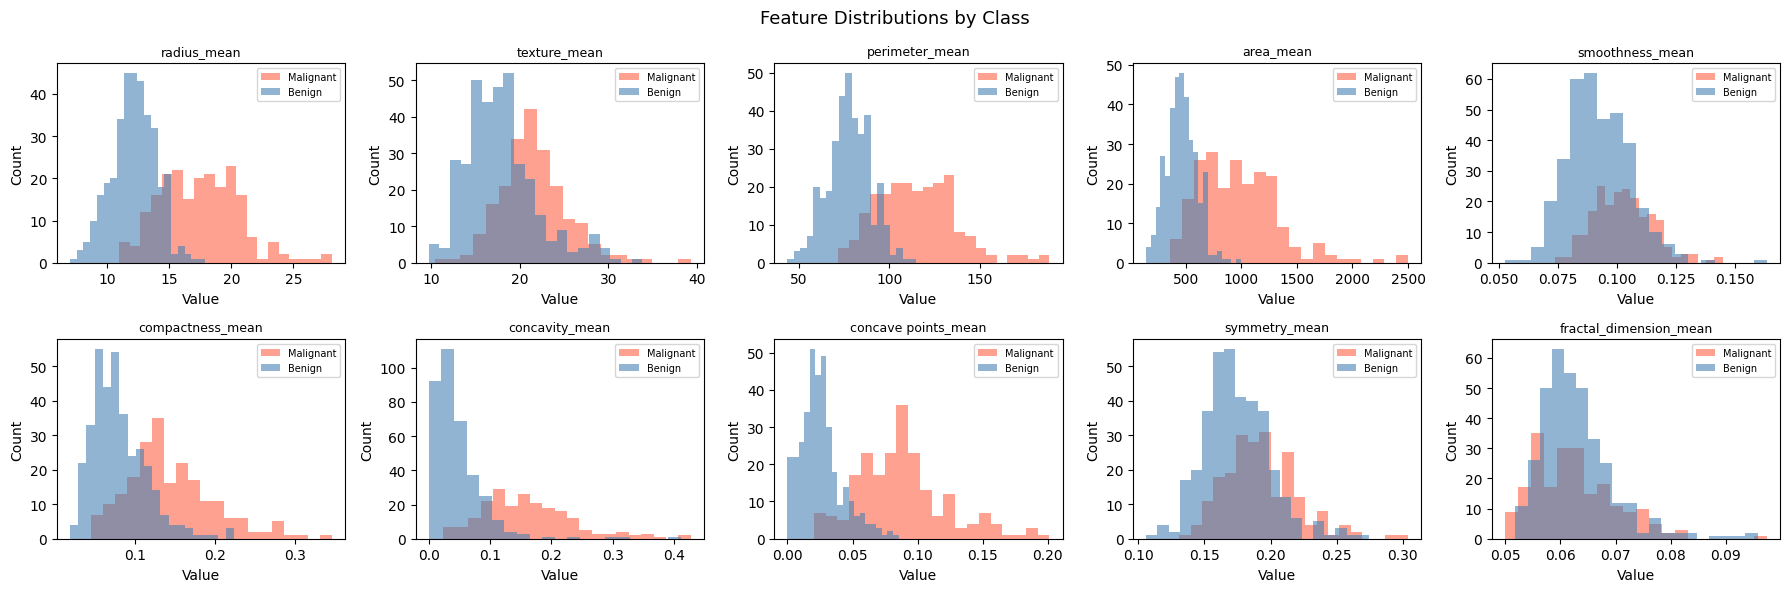

In [ ]:
# CELL 5: EDA — Histograms of first 10 features

features_to_plot = X.columns[:10]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for ax, feature in zip(axes.ravel(), features_to_plot):

    malignant = X[feature][y == 0]
    benign    = X[feature][y == 1]

    ax.hist(malignant, bins=20, alpha=0.6, color='tomato',   label='Malignant')
    ax.hist(benign,    bins=20, alpha=0.6, color='steelblue', label='Benign')

    ax.set_title(feature, fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Feature Distributions by Class', fontsize=13)
plt.tight_layout()
plt.show()

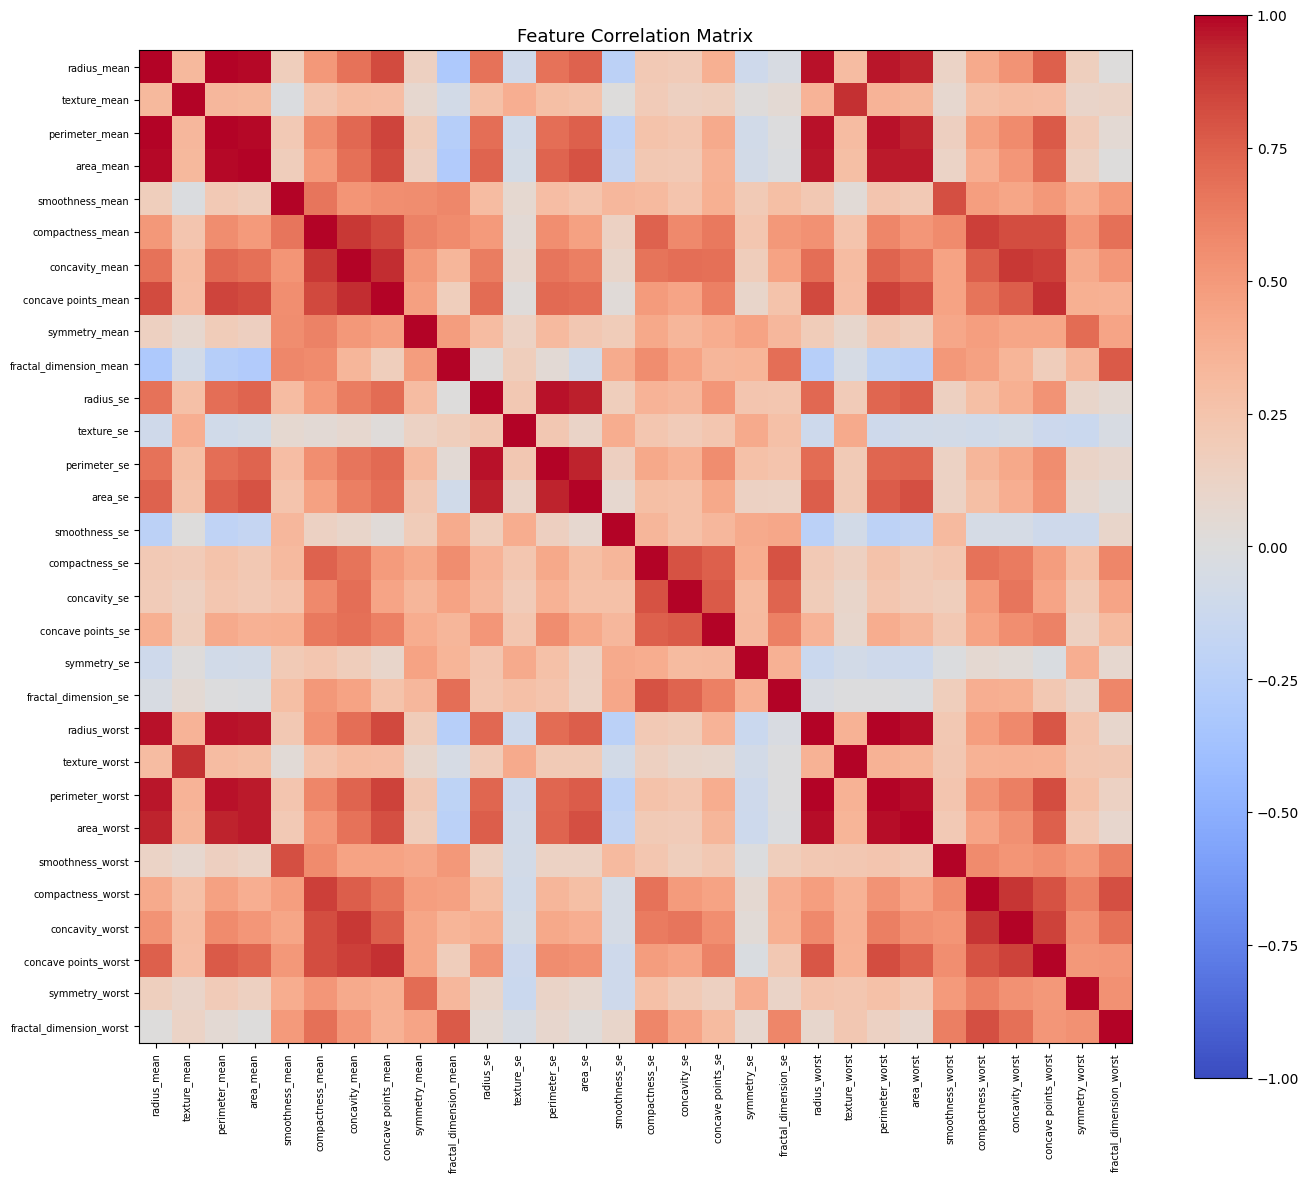

In [ ]:
# CELL 6: EDA — Correlation matrix

corr_matrix = X.corr()

fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr_matrix.columns, fontsize=7)

ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# CELL 7: Data Splitting — Stratified Hold-Out

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Dataset sizes:")
print(f"  X_train: {X_train.shape}  →  {len(X_train)} samples")
print(f"  X_test:  {X_test.shape}   →  {len(X_test)} samples")

print("\nClass distribution in y_train:")
print(y_train.value_counts())

print("\nClass distribution in y_test:")
print(y_test.value_counts())

print(f"\nBenign ratio in train: {y_train.mean():.2f}")
print(f"Benign ratio in test:  {y_test.mean():.2f}")

Dataset sizes:
  X_train: (455, 30)  →  455 samples
  X_test:  (114, 30)   →  114 samples

Class distribution in y_train:
diagnosis
1    285
0    170
Name: count, dtype: int64

Class distribution in y_test:
diagnosis
1    72
0    42
Name: count, dtype: int64

Benign ratio in train: 0.63
Benign ratio in test:  0.63


In [ ]:
# CELL 8: Preprocessing — StandardScaler

from sklearn.preprocessing import StandardScaler

# Create the scaler (standardizes features to mean=0, std=1)
scaler = StandardScaler()

# Fit on training data ONLY and transform it (learns mean/std from train)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the SAME parameters learned from train (no fit -> no leakage)
X_test_scaled = scaler.transform(X_test)

# Check one feature before scaling (original scale)
print("Before scaling (X_train):")
print(f"  radius_mean — mean: {X_train['radius_mean'].mean():.2f}, std: {X_train['radius_mean'].std():.2f}")

# Check same feature after scaling (should be mean~0, std~1)
print("\nAfter scaling (X_train_scaled):")
print(f"  feature 0  — mean: {X_train_scaled[:, 0].mean():.4f}, std: {X_train_scaled[:, 0].std():.4f}")
print("  -> mean = 0, std = 1 ")


Before scaling (X_train):
  radius_mean — mean: 14.07, std: 3.50

After scaling (X_train_scaled):
  feature 0  — mean: -0.0000, std: 1.0000
  -> mean = 0, std = 1 


In [ ]:
# CELL 9: Data Leakage Checklist

# Print a checklist confirming each type of data leakage (from File 6) is avoided
print("DATA LEAKAGE CHECKLIST")

# L1.1 - train and test must be separate datasets
print("\nL1.1 — No test set?")
print("   SAFE: We have separate X_train and X_test")

# L1.2 - scaler must be fit only on train, not on the full dataset
print("\nL1.2 — Pre-processing on full dataset?")
print("   SAFE: scaler.fit() called ONLY on X_train")
print("          scaler.transform() applied to X_test separately")

# L1.3 - no feature selection done using the whole dataset
print("\nL1.3 — Feature selection on full dataset?")
print("   SAFE: We use all features without selection on full data")

# L1.4 - check there are no identical rows shared by train and test
print("\nL1.4 — Duplicates across train and test?")
train_df = pd.DataFrame(X_train_scaled)
test_df  = pd.DataFrame(X_test_scaled)

# merge with how='inner' returns rows that appear in BOTH sets
merged = train_df.merge(test_df, how='inner')
print(f"   SAFE: {len(merged)} duplicate samples found between train and test")

# L2 - features must not directly reveal the diagnosis
print("\nL2 — Illegitimate features?")
print("   SAFE: WDBC features are biopsy measurements, not diagnosis-derived")

# L3.2 - each sample must be an independent patient
print("\nL3.2 — Non-independence?")
print("   SAFE: Each row = one unique patient biopsy in WDBC")

print("All leakage checks passed!")


DATA LEAKAGE CHECKLIST

L1.1 — No test set?
   SAFE: We have separate X_train and X_test

L1.2 — Pre-processing on full dataset?
   SAFE: scaler.fit() called ONLY on X_train
          scaler.transform() applied to X_test separately

L1.3 — Feature selection on full dataset?
   SAFE: We use all features without selection on full data

L1.4 — Duplicates across train and test?
   SAFE: 0 duplicate samples found between train and test

L2 — Illegitimate features?
   SAFE: WDBC features are biopsy measurements, not diagnosis-derived

L3.2 — Non-independence?
   SAFE: Each row = one unique patient biopsy in WDBC
All leakage checks passed!


In [ ]:
# CELL 10: sklearn Pipeline

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Each pipeline = StandardScaler + classifier, so scaling is done correctly
# inside every CV fold automatically (prevents data leakage)
pipelines = {

    # Linear model; max_iter raised so the solver converges
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
    ]),

    # Ensemble of decision trees
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(random_state=RANDOM_STATE))
    ]),

    # Support Vector Machine; probability=True needed to compute ROC AUC
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(random_state=RANDOM_STATE, probability=True))
    ]),

    # Distance-based model (k nearest neighbors)
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])
}

# Print the steps of each pipeline to confirm they were built
print("Pipelines created successfully:")
for name, pipe in pipelines.items():
    print(f"  {name}: {[step[0] for step in pipe.steps]}")


Pipelines created successfully:
  Logistic Regression: ['scaler', 'clf']
  Random Forest: ['scaler', 'clf']
  SVM: ['scaler', 'clf']
  KNN: ['scaler', 'clf']


In [ ]:
# CELL 11: Nested CV + GridSearch

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)
import numpy as np

# Outer loop: 5 folds, used to honestly evaluate the models
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Inner loop: 3 folds, used only to tune hyperparameters
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Hyperparameter grids for each model ('clf__' refers to the classifier step)
param_grids = {

    'Logistic Regression': {
        'clf__C': [0.01, 0.1, 1, 10]            # C = regularization strength
    },

    'Random Forest': {
        'clf__n_estimators': [50, 100],          # number of trees
        'clf__max_depth': [None, 5, 10]          # depth of each tree
    },

    'SVM': {
        'clf__C': [0.1, 1, 10],                  # regularization strength
        'clf__kernel': ['linear', 'rbf']         # linear or non-linear boundary
    },

    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 9]         # number of neighbors
    }
}

# Dictionary to store the results of each model
nested_cv_results = {}

print("Starting Nested CV...\n")

for name, pipeline in pipelines.items():

    # Inner loop: search the best hyperparameters using 3-fold CV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=inner_cv,
        scoring='roc_auc',
        refit=True,
        n_jobs=-1                                # use all CPU cores
    )

    # Outer loop: evaluate the tuned model on unseen outer folds
    outer_scores = cross_val_score(
        estimator=grid_search,
        X=X,                                     # whole dataset; outer CV splits it
        y=y,
        cv=outer_cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    # Save AUC scores, mean (main metric) and std (stability)
    nested_cv_results[name] = {
        'scores': outer_scores,
        'mean': outer_scores.mean(),
        'std': outer_scores.std()
    }

    print(f"{name}:")
    print(f"  ROC AUC per fold: {outer_scores.round(3)}")
    print(f"  Mean ± Std: {outer_scores.mean():.3f} ± {outer_scores.std():.3f}\n")


Starting Nested CV...

Logistic Regression:
  ROC AUC per fold: [0.998 0.997 0.974 1.    0.999]
  Mean ± Std: 0.994 ± 0.010

Random Forest:
  ROC AUC per fold: [0.998 0.975 0.979 0.996 0.994]
  Mean ± Std: 0.988 ± 0.009

SVM:
  ROC AUC per fold: [1.    0.99  0.985 1.    0.998]
  Mean ± Std: 0.995 ± 0.006

KNN:
  ROC AUC per fold: [0.997 0.983 0.968 0.999 0.995]
  Mean ± Std: 0.988 ± 0.012



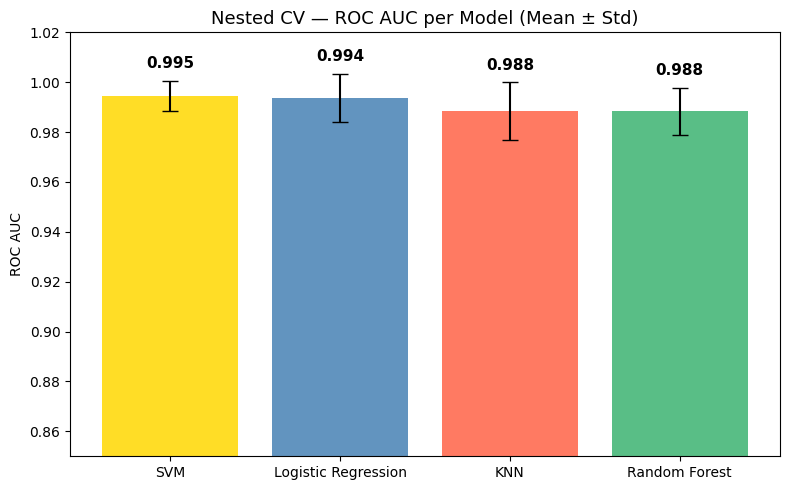


Final Nested CV Results (sorted by ROC AUC):
---------------------------------------------
Model                   Mean AUC      Std
---------------------------------------------
SVM                        0.995    0.006
Logistic Regression        0.994    0.010
KNN                        0.988    0.012
Random Forest              0.988    0.009
---------------------------------------------

Best model: SVM (ROC AUC = 0.995)


In [ ]:
# CELL 12: Comparison between models with CV + visualization

# Collect model names, mean AUCs and stds
names  = list(nested_cv_results.keys())
means  = [nested_cv_results[n]['mean'] for n in names]
stds   = [nested_cv_results[n]['std']  for n in names]

# Sort models from best to worst by mean AUC
sorted_idx = np.argsort(means)[::-1]
names_sorted = [names[i] for i in sorted_idx]
means_sorted = [means[i] for i in sorted_idx]
stds_sorted  = [stds[i]  for i in sorted_idx]

# Bar chart of mean AUC with error bars (std)
plt.figure(figsize=(8, 5))

bars = plt.bar(
    names_sorted,
    means_sorted,
    yerr=stds_sorted,                            # error bars = std
    capsize=6,
    color=['gold', 'steelblue', 'tomato', 'mediumseagreen'],
    alpha=0.85
)

# Write the AUC value on top of each bar
for bar, mean, std in zip(bars, means_sorted, stds_sorted):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        mean + std + 0.005,
        f'{mean:.3f}',
        ha='center', fontsize=11, fontweight='bold'
    )

plt.title('Nested CV — ROC AUC per Model (Mean ± Std)', fontsize=13)
plt.ylabel('ROC AUC')
plt.ylim(0.85, 1.02)
plt.tight_layout()
plt.show()

# Print a sorted results table
print("\nFinal Nested CV Results (sorted by ROC AUC):")
print("-" * 45)
print(f"{'Model':<22} {'Mean AUC':>9} {'Std':>8}")
print("-" * 45)
for n, m, s in zip(names_sorted, means_sorted, stds_sorted):
    print(f"{n:<22} {m:>9.3f} {s:>8.3f}")
print("-" * 45)

# Print the best model by mean AUC
best_model_name = names_sorted[0]
print(f"\nBest model: {best_model_name} (ROC AUC = {means_sorted[0]:.3f})")


In [ ]:
# CELL 13: Best Hyperparameter for each model

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Inner 3-fold CV used to pick the best hyperparameters on the training data
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Dictionary to store the best fitted model for each algorithm
best_estimators = {}

print("Finding best hyperparameters for each model...\n")

for name, pipeline in pipelines.items():

    # Search all hyperparameter combinations and keep the best by ROC AUC
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=inner_cv,
        scoring='roc_auc',
        refit=True,                              # retrain on all train data with best params
        n_jobs=-1
    )

    # Fit on training data; the pipeline scales inside each fold
    grid_search.fit(X_train, y_train)

    # Store the best fitted model
    best_estimators[name] = grid_search.best_estimator_

    print(f"{name}:")
    print(f"  Best params : {grid_search.best_params_}")
    print(f"  Best CV AUC : {grid_search.best_score_:.3f}\n")


Finding best hyperparameters for each model...

Logistic Regression:
  Best params : {'clf__C': 1}
  Best CV AUC : 0.995

Random Forest:
  Best params : {'clf__max_depth': None, 'clf__n_estimators': 100}
  Best CV AUC : 0.991

SVM:
  Best params : {'clf__C': 1, 'clf__kernel': 'rbf'}
  Best CV AUC : 0.995

KNN:
  Best params : {'clf__n_neighbors': 9}
  Best CV AUC : 0.992



In [ ]:
# CELL 14: Evaluation for Test set

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# This is the FIRST time we use the test set (kept untouched until now)
evaluation_results = {}

for name, model in best_estimators.items():

    # Predict class labels (0 or 1)
    y_pred = model.predict(X_test)

    # Predict probability of class 1 (needed for ROC AUC and ROC curve)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Area under the ROC curve (1.0 = perfect, 0.5 = random)
    auc = roc_auc_score(y_test, y_prob)

    # Confusion matrix: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y_test, y_pred)

    # Points to draw the ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Store everything for the plots and table below
    evaluation_results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auc'   : auc,
        'cm'    : cm,
        'fpr'   : fpr,
        'tpr'   : tpr
    }

    # Print the metrics for this model
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  ROC AUC: {auc:.3f}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"    FN={cm[1,0]}  TP={cm[1,1]}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Malignant', 'Benign']))


  Logistic Regression
  ROC AUC: 0.995

  Confusion Matrix:
    TN=41  FP=1
    FN=1  TP=71

  Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

  Random Forest
  ROC AUC: 0.994

  Confusion Matrix:
    TN=39  FP=3
    FN=2  TP=70

  Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

  SVM
  ROC AUC: 0.995

  Confusion Matrix:
    TN=41  FP=1
    FN=1  TP=71

  Classification Report:
              

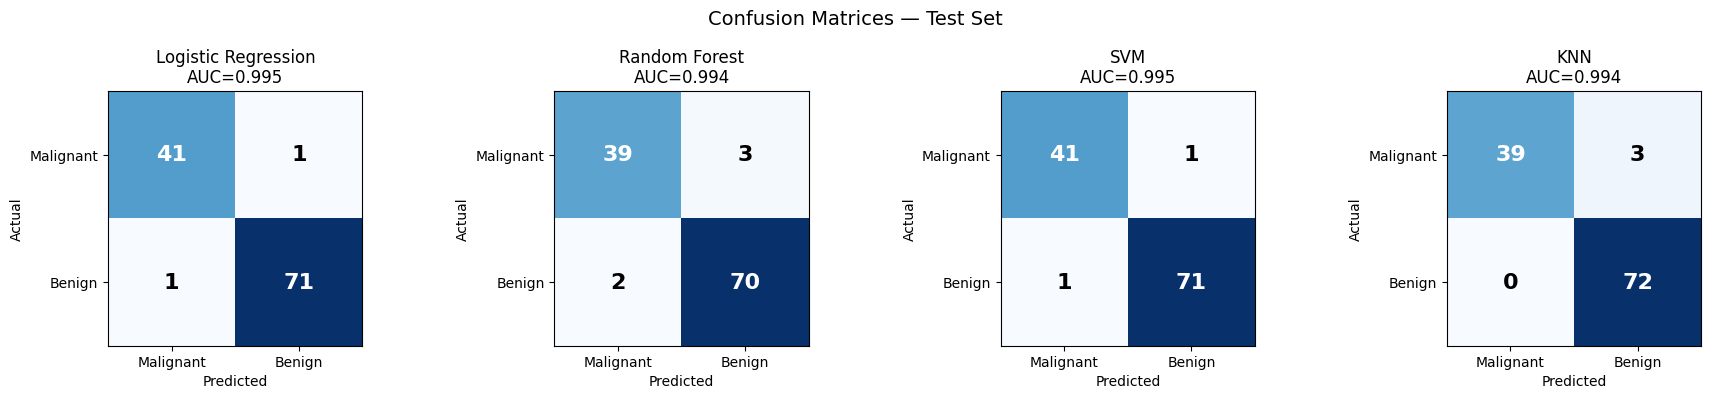

In [ ]:
# CELL 15: Confusion Matrices

# One confusion matrix per model, side by side
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, res) in zip(axes, evaluation_results.items()):
    cm = res['cm']

    # Show the matrix as a colored grid (darker = higher count)
    im = ax.imshow(cm, cmap='Blues')

    # Axis labels
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Malignant', 'Benign'])
    ax.set_yticklabels(['Malignant', 'Benign'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name}\nAUC={res["auc"]:.3f}')

    # Write the count inside each cell
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

plt.suptitle('Confusion Matrices — Test Set', fontsize=14)
plt.tight_layout()
plt.show()


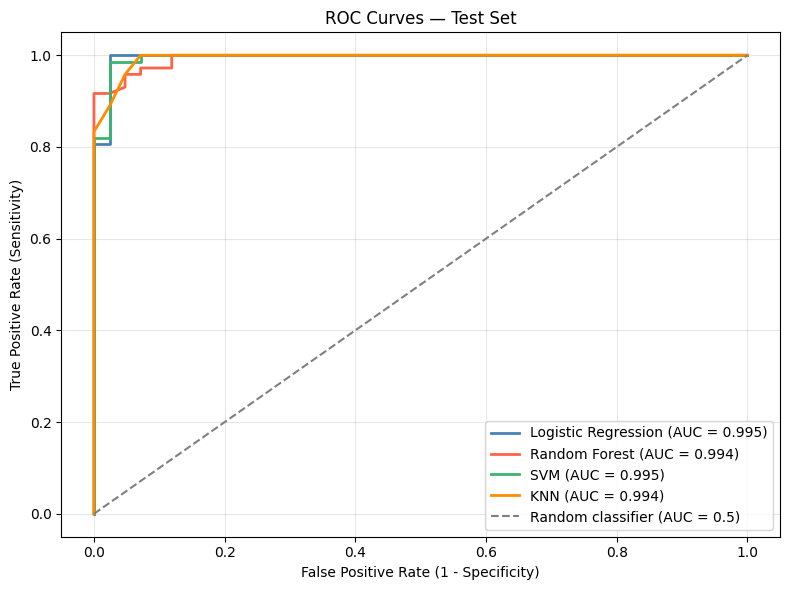

In [ ]:
# CELL 16: ROC Curves

# Colors for the four models
colors = ['steelblue', 'tomato', 'mediumseagreen', 'darkorange']

plt.figure(figsize=(8, 6))

# Plot one ROC curve per model
for (name, res), color in zip(evaluation_results.items(), colors):
    plt.plot(
        res['fpr'], res['tpr'],
        label=f"{name} (AUC = {res['auc']:.3f})",
        color=color, linewidth=2
    )

# Diagonal line = random classifier (AUC = 0.5)
plt.plot([0, 1], [0, 1],
         linestyle='--', color='gray',
         label='Random classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves — Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# CELL 17: Comparison table

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Print a header for the metrics table
print(f"\n{'Model':<22} {'AUC':>6} {'Acc':>6} {'Prec':>6} {'Rec':>6} {'F1':>6}")
print("-" * 55)

summary = {}
for name, res in evaluation_results.items():
    # Compute the main classification metrics on the test set
    acc  = accuracy_score (y_test, res['y_pred'])
    prec = precision_score(y_test, res['y_pred'])
    rec  = recall_score   (y_test, res['y_pred'])
    f1   = f1_score       (y_test, res['y_pred'])
    auc  = res['auc']

    summary[name] = {'AUC': auc, 'Accuracy': acc,
                     'Precision': prec, 'Recall': rec, 'F1': f1}

    print(f"{name:<22} {auc:>6.3f} {acc:>6.3f} {prec:>6.3f} {rec:>6.3f} {f1:>6.3f}")

print("-" * 55)

# Pick and print the best model by AUC
best_name = max(summary, key=lambda n: summary[n]['AUC'])
print(f"\nBest model by AUC: {best_name} → {summary[best_name]['AUC']:.3f}")



Model                     AUC    Acc   Prec    Rec     F1
-------------------------------------------------------
Logistic Regression     0.995  0.982  0.986  0.986  0.986
Random Forest           0.994  0.956  0.959  0.972  0.966
SVM                     0.995  0.982  0.986  0.986  0.986
KNN                     0.994  0.974  0.960  1.000  0.980
-------------------------------------------------------

Best model by AUC: Logistic Regression → 0.995


In [ ]:
# CELL 18: Final Model

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Best model from Nested CV: Logistic Regression with C=1
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1, max_iter=1000, random_state=RANDOM_STATE))
])

# Retrain the final model on the ENTIRE dataset (Nested CV already gave a fair estimate)
final_pipeline.fit(X, y)

print("Final Model: Logistic Regression (C=1)")
print("Trained on: entire dataset (569 samples)")
print("Expected performance (from Nested CV): AUC = 0.994 ± 0.010")
print("\nFinal model trained (for educational purposes only).")


Final Model: Logistic Regression (C=1)
Trained on: entire dataset (569 samples)
Expected performance (from Nested CV): AUC = 0.994 ± 0.010

Final model trained (for educational purposes only).


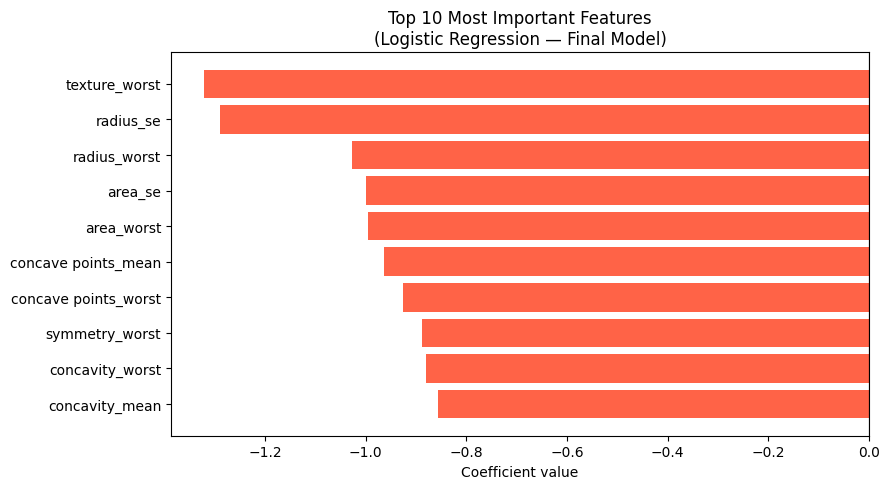


Top 5 features:
  texture_worst                  coef=-1.321  → Malignant
  radius_se                      coef=-1.289  → Malignant
  radius_worst                   coef=-1.027  → Malignant
  area_se                        coef=-0.999  → Malignant
  area_worst                     coef=-0.995  → Malignant


In [ ]:
# CELL 19: Feature Importance

import numpy as np

# Logistic Regression coefficients show how each feature affects the prediction
# Positive -> pushes towards Benign (1), Negative -> pushes towards Malignant (0)
coefficients = final_pipeline.named_steps['clf'].coef_[0]
feature_names = X.columns.tolist()

# Sort features by absolute coefficient (most important first)
sorted_idx = np.argsort(np.abs(coefficients))[::-1]
top_n = 10

# Keep the top 10 features and their coefficients
top_features = [feature_names[i] for i in sorted_idx[:top_n]]
top_coefs    = [coefficients[i]  for i in sorted_idx[:top_n]]

# Blue = points to Benign, Red = points to Malignant
colors = ['steelblue' if c > 0 else 'tomato' for c in top_coefs]

# Horizontal bar chart of the top 10 features
plt.figure(figsize=(9, 5))
bars = plt.barh(top_features[::-1], top_coefs[::-1], color=colors[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient value')
plt.title('Top 10 Most Important Features\n(Logistic Regression — Final Model)')
plt.tight_layout()
plt.show()

# Print the top 5 features with their direction
print("\nTop 5 features:")
for feat, coef in zip(top_features[:5], top_coefs[:5]):
    direction = '→ Benign' if coef > 0 else '→ Malignant'
    print(f"  {feat:<30} coef={coef:+.3f}  {direction}")


In [ ]:
# CELL 20: Reproducibility Report

import sklearn
import numpy as np
import pandas as pd
import matplotlib

# Print all information needed to reproduce the project (File 7)
print("=" * 50)
print("REPRODUCIBILITY REPORT")
print("=" * 50)

# Library versions used
print("\n1. Library versions:")
print(f"   numpy      : {np.__version__}")
print(f"   pandas     : {pd.__version__}")
print(f"   matplotlib : {matplotlib.__version__}")
print(f"   sklearn    : {sklearn.__version__}")

# Fixed random seed for reproducibility
print("\n2. Random seeds fixed:")
print(f"   RANDOM_STATE = {RANDOM_STATE} (used in all models, splits, CV)")

# Dataset information
print("\n3. Dataset:")
print(f"   Name    : Wisconsin Diagnostic Breast Cancer (WDBC)")
print(f"   Source  : Kaggle (Breast Cancer Wisconsin Diagnostic) - loaded from Google Drive: /content/drive/MyDrive/Colab Notebooks/data.csv")
print(f"   Samples : {X.shape[0]}")
print(f"   Features: {X.shape[1]}")
print(f"   Classes : Malignant=0, Benign=1")

# Validation strategy
print("\n4. Validation strategy:")
print(f"   Method  : Stratified Nested Cross-Validation")
print(f"   Outer CV: 5-fold Stratified KFold")
print(f"   Inner CV: 3-fold Stratified KFold (GridSearchCV)")
print(f"   Metric  : ROC AUC")

# Final model details
print("\n5. Final model:")
print(f"   Algorithm : Logistic Regression")
print(f"   Best C    : 1")
print(f"   Trained on: entire dataset (569 samples)")
print(f"   Nested CV AUC: 0.994 ± 0.010")

# Data leakage prevention summary
print("\n6. Data Leakage prevention:")
print(f"   - StandardScaler fit ONLY on training folds")
print(f"   - sklearn Pipeline used throughout")
print(f"   - Test set used ONLY in CELL 14 for final evaluation")
print(f"   - No duplicates found between train and test")

print("\n" + "=" * 50)
print("All steps documented for full reproducibility.")
print("=" * 50)


REPRODUCIBILITY REPORT

1. Library versions:
   numpy      : 2.0.2
   pandas     : 2.2.2
   matplotlib : 3.10.0
   sklearn    : 1.6.1

2. Random seeds fixed:
   RANDOM_STATE = 42 (used in all models, splits, CV)

3. Dataset:
   Name    : Wisconsin Diagnostic Breast Cancer (WDBC)
   Source  : Kaggle (Breast Cancer Wisconsin Diagnostic) - loaded from Google Drive: /content/drive/MyDrive/Colab Notebooks/data.csv
   Samples : 569
   Features: 30
   Classes : Malignant=0, Benign=1

4. Validation strategy:
   Method  : Stratified Nested Cross-Validation
   Outer CV: 5-fold Stratified KFold
   Inner CV: 3-fold Stratified KFold (GridSearchCV)
   Metric  : ROC AUC

5. Final model:
   Algorithm : Logistic Regression
   Best C    : 1
   Trained on: entire dataset (569 samples)
   Nested CV AUC: 0.994 ± 0.010

6. Data Leakage prevention:
   - StandardScaler fit ONLY on training folds
   - sklearn Pipeline used throughout
   - Test set used ONLY in CELL 14 for final evaluation
   - No duplicates fo